# EDA - EXPLORATORY DATA ANALYSIS

In [6]:
#for data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#for outliers
from statsmodels.stats.outliers_influence import variance_inflation_factor

## FUNCTION DEFINITON AND LOADING

- Show variable values over time

In [34]:
# Function to display Q-Q plots for continuous variables
def time_series(df, columns=None):
    """
    Plots time series line plots for continuous numerical columns in the DataFrame.
    
    Parameters:
    - df: The DataFrame containing the data.
    - columns: List of columns to plot. If None, plots all continuous numeric columns.
    """
    # If no columns are specified, use only float (continuous) columns
    if columns is None:
        columns = df.select_dtypes(include=['float']).columns  # Select only float columns
    
    # Set up the subplots
    num_columns = len(columns)
    fig, axes = plt.subplots(num_columns, 1, figsize=(10, num_columns * 3), squeeze=False)

    # Plot each time series
    for i, column in enumerate(columns):
        axes[i, 0].plot(df["date"], df[column])
        axes[i, 0].set_title(f'Value of {column}')
        axes[i, 0].set_xlabel('Date')
        axes[i, 0].set_ylabel(column)

    plt.tight_layout()
    plt.show()


- QQ-plot function

In [ ]:
# Function to display Q-Q plots for continuous variables
def col_qqplots(df, columns=None):
    """
    Plots Q-Q plots for continuous numerical columns in the DataFrame to assess normality.
    
    Parameters:
    - df: The DataFrame containing the data.
    - columns: List of columns to plot. If None, plots all continuous numeric columns.
    """
    # If no columns are specified, use only float (continuous) columns
    if columns is None:
        columns = df.select_dtypes(include=['float']).columns  # Select only float columns
    
    # Set up the subplots
    num_columns = len(columns)
    fig, axes = plt.subplots(num_columns, 1, figsize=(8, num_columns * 3), squeeze=False)
    
    # Plot Q-Q plots for each column
    for i, column in enumerate(columns):
        stats.probplot(df[column].dropna(), dist="norm", plot=axes[i, 0])  # Q-Q plot against normal distribution
        axes[i, 0].set_title(f'Q-Q Plot of {column}')
        axes[i, 0].set_xlabel('Theoretical Quantiles')
        axes[i, 0].set_ylabel('Sample Quantiles')
    
    plt.tight_layout()
    plt.show()

- Boxplots function

In [8]:
#build a function to displays boxplot
def col_boxplots(df, columns=None):
    """
    Plots individual box plots for each specified column in the DataFrame.
    
    Parameters:
    - df: The DataFrame containing the data.
    - columns: List of columns to plot. If None, plots all numeric columns.
    """
    # If no columns are specified, use all numeric columns
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    # Set up the subplots
    num_columns = len(columns)
    fig, axes = plt.subplots(num_columns, 1, figsize=(8, num_columns * 2), squeeze=False)
    
    # Plot each column on a separate subplot
    for i, column in enumerate(columns):
        sns.boxplot(data=df, x=column, ax=axes[i, 0])
        axes[i, 0].set_title(f'Box plot of {column}')
        axes[i, 0].set_xlabel('Values')
        axes[i, 0].set_ylabel(column)
    
    plt.tight_layout()
    plt.show()

- Distribution Pots function

In [9]:
# Function to display distribution plots
def col_distributions(df, columns=None):
    """
    Plots distribution plots for each specified column in the DataFrame.
    
    Parameters:
    - df: The DataFrame containing the data.
    - columns: List of columns to plot. If None, plots all numeric columns.
    """
    # If no columns are specified, use all numeric columns
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    # Set up the subplots
    num_columns = len(columns)
    fig, axes = plt.subplots(num_columns, 1, figsize=(8, num_columns * 3), squeeze=False)
    
    # Plot each column's distribution
    for i, column in enumerate(columns):
        sns.histplot(data=df, x=column, kde=True, ax=axes[i, 0], bins=30)
        axes[i, 0].set_title(f'Distribution of {column}')
        axes[i, 0].set_xlabel('Values')
        axes[i, 0].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

- Multicollinearity check

In [10]:
#function to compute either correlation matrix or VIF
def check_multicollinearity(df, method="correlation", threshold=0.7):
    """
    Checks for multicollinearity in the numerical columns of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        method (str): Method to use for checking multicollinearity.
                      "correlation" - Show correlation matrix with high correlations flagged.
                      "vif" - Compute Variance Inflation Factor (VIF) for numerical columns.
        threshold (float): Correlation threshold for flagging multicollinearity (for correlation method).
    
    Returns:
        pd.DataFrame or dict: Correlation matrix or VIF scores depending on the method.
    """
    # Select only numerical columns
    numerical_df = df.select_dtypes(include=[np.number])
    
    if method == "correlation":
        # Compute the correlation matrix
        corr_matrix = numerical_df.corr()
        # Flag correlations above the threshold
        high_corr = (corr_matrix.abs() >= threshold) & (corr_matrix != 1.0)
        return corr_matrix, high_corr
    
    elif method == "vif":
        # Compute VIF for each numerical column
        vif_data = pd.DataFrame()
        vif_data["feature"] = numerical_df.columns
        vif_data["VIF"] = [variance_inflation_factor(numerical_df.values, i) for i in range(len(numerical_df.columns))]
        return vif_data
    
    else:
        raise ValueError("Invalid method. Use 'correlation' or 'vif'.")

- Pie chart plotting function

In [11]:
def pie_chart(df, column, ax, title):
    """
    Create a pie chart for a given column in the specified subplot axis.
    """
    counts = df[column].value_counts()
    labels = counts.index.astype(str)
    
    ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    ax.set_title(title)

## EDA

The first step is to load the already cleaned dataset.

In [12]:
#load the cleaned dataset
df = pd.read_csv("../data/crypto_volatility_clean.csv")
#check it has been properly loaded
df.head(5)


,date,open,high,low,close,volume,trend,fg_index
0,2018-02-01,10285.10,10335.00,8750.99,9224.52,33564.764311,45,30.0
1,2018-02-02,9224.52,9250.00,8010.02,8873.03,49971.626975,65,15.0
2,2018-02-03,8873.03,9473.01,8229.00,9199.96,28725.000735,42,40.0
3,2018-02-04,9199.96,9368.00,7930.00,8184.81,32014.308449,34,24.0
4,2018-02-05,8179.99,8382.80,6625.00,6939.99,63403.182579,63,11.0


Let's show some details about the variables.

In [13]:
#show df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      2644 non-null   object 
 1   open      2644 non-null   float64
 2   high      2644 non-null   float64
 3   low       2644 non-null   float64
 4   close     2644 non-null   float64
 5   volume    2644 non-null   float64
 6   trend     2644 non-null   int64  
 7   fg_index  2644 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 165.4+ KB


Change date column from object to "datetime"

In [14]:
#change timestamp to datetime object
df["date"] = pd.to_datetime(df["date"])
#check it
df.dtypes

date        datetime64[ns]
open               float64
high               float64
low                float64
close              float64
volume             float64
trend                int64
fg_index           float64
dtype: object

Some useful insights:  
  
- the df is made of 8 columns and 2644 rows
- Most variables are decimals. There are just one integer and one datetime objects.  
- As the df is the cleaned one, there are not missing values.  
  

Let's shift the focus to each single variable and:  
  
- display it
- display its boxplot  


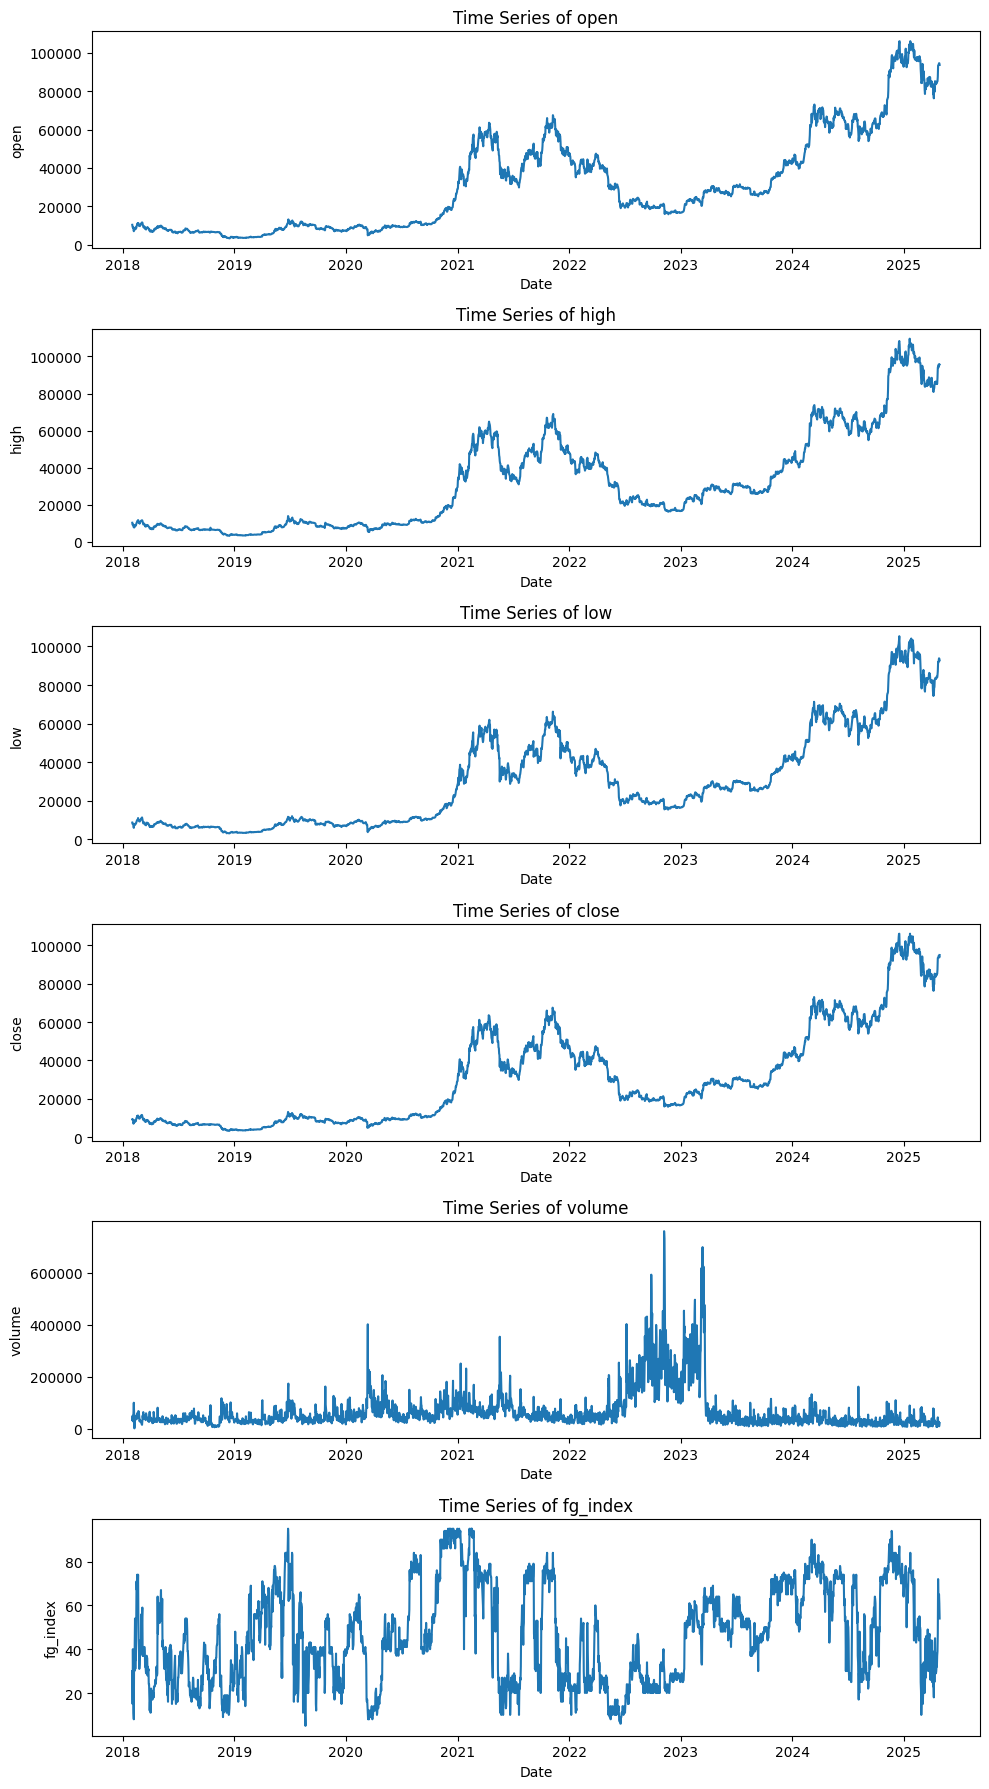

In [33]:
#show a variable
time_series(df)

Open, close, high, and low prices show similar trends. From 2018 to 2021, values remained relatively flat and low. In 2021, prices surged but were almost immediately followed by a sharp decline in 2022. Since then, there has been a general upward trend, albeit with notable fluctuations.  
  
Trading volume spiked significantly between mid-2022 and mid-2023. Outside of this period, it remained relatively stable with occasional peaks.  
  
Finally, the Fear and Greed Index (FGI) exhibits frequent ups and downs, highlighting the volatility in market sentiment and how quickly perceptions of Bitcoin can shift.  
  
Note Trend is missing as it is not a continuos variable.

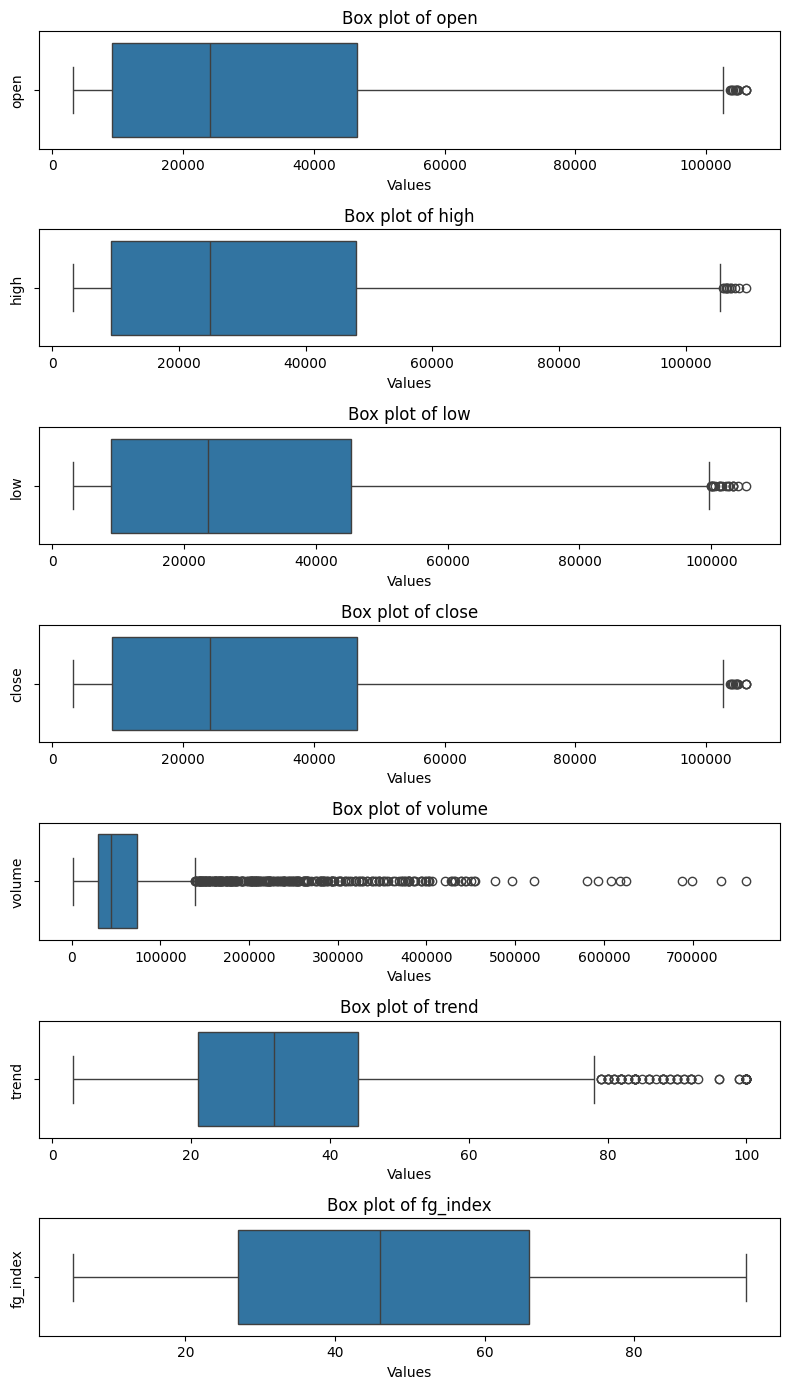

In [15]:
#show boxplots
col_boxplots(df)

A couple of remarks:  
  
- Volume has more outliers than any other variable.  
- Open, high, low and closed have all similary boxplots.
- Variables have different scaled. Therefore, data must be scaled before being plugged into some models.

Let's double check the variables' distribution and qq-plots too.

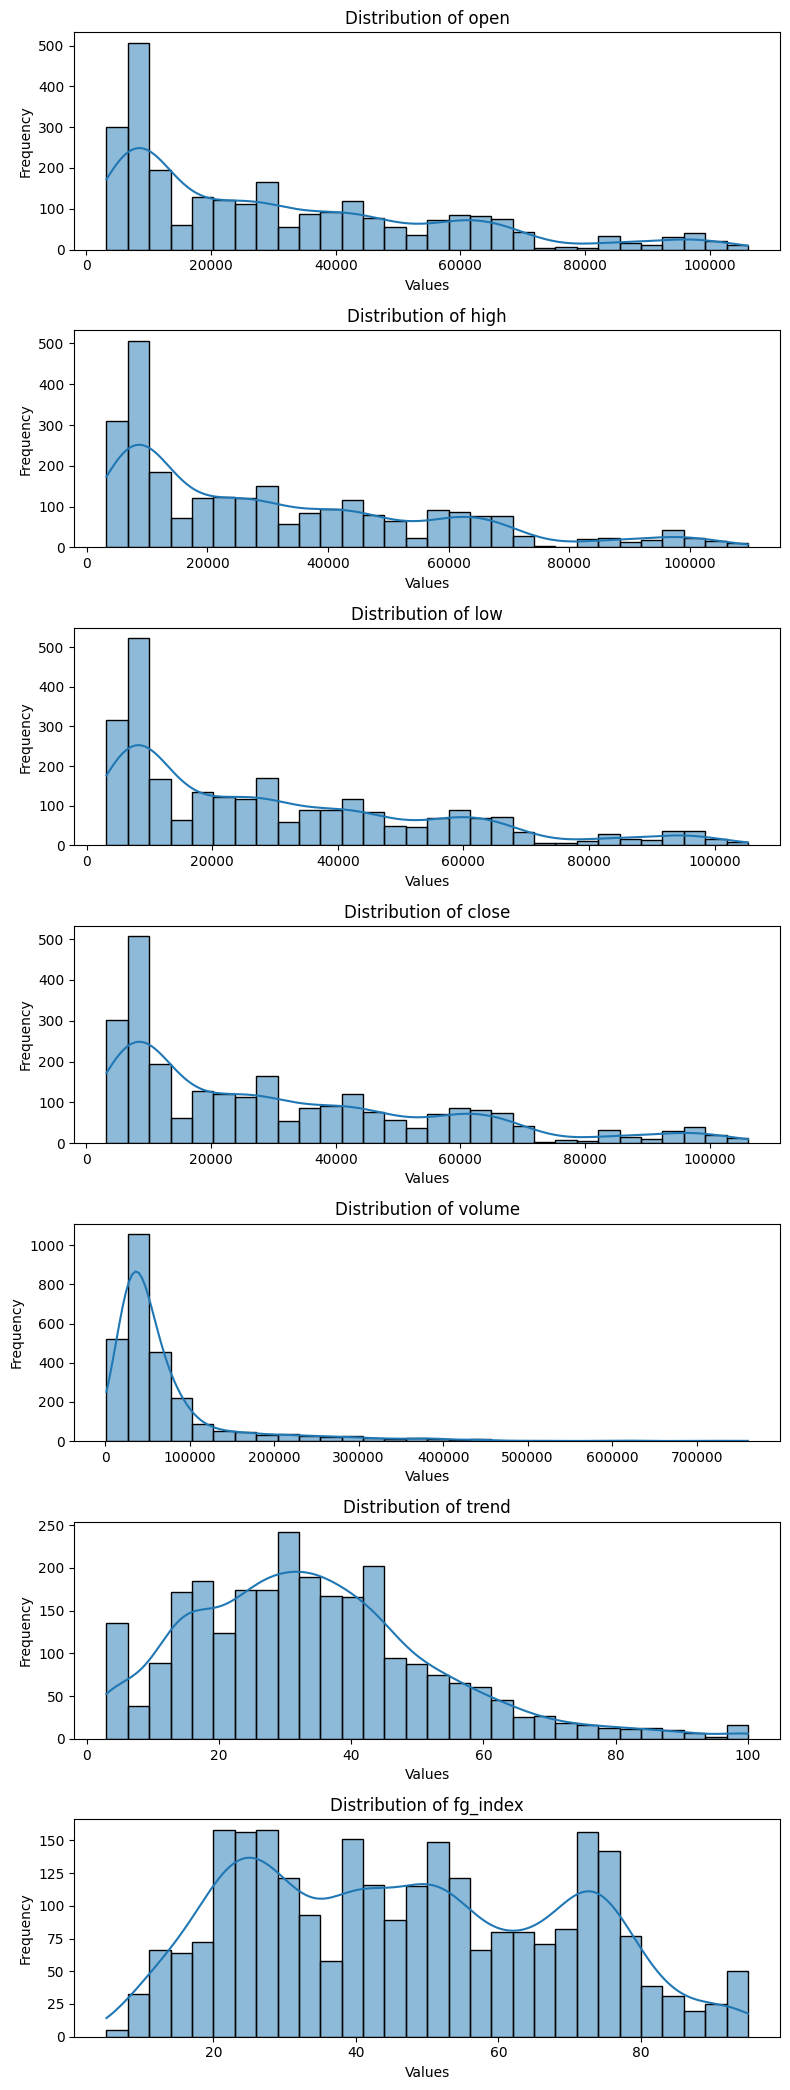

In [16]:
col_distributions(df)

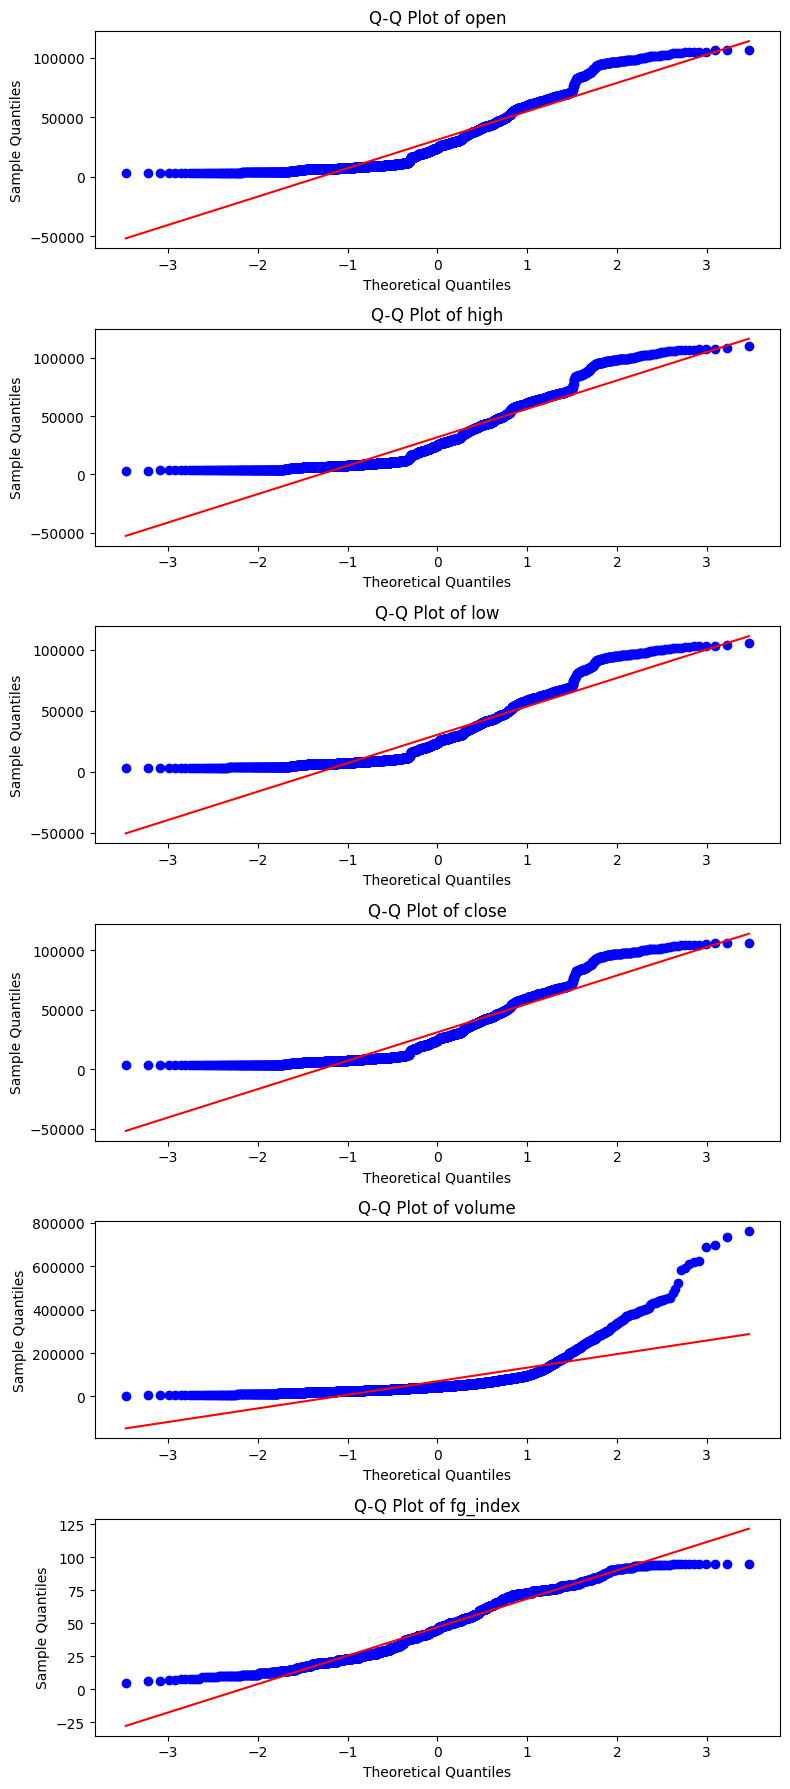

In [18]:
col_qqplots(df)

As the plots above show, none of the variables follow a normal distribution. This is expected, as financial data typically exhibit trends, volatility clusters, and non-stationary behavior rather than bell-shaped distributions.  
  
This is important to consider when using models that assume normality, to avoid violating underlying statistical assumptions.

Let's now consider how variables interact amongst one another by displaying both multicollinearity matrix and the VIF score.

In [20]:
#correlation matrix
print("Correlation Matrix with threshold = 0.4:")
print("--------------------------------------------------")
check_multicollinearity(df, method="correlation", threshold=0.4)

Correlation Matrix with threshold = 0.4:
--------------------------------------------------


(              open      high       low     close    volume     trend  fg_index
 open      1.000000  0.999435  0.999164  0.998837 -0.155732  0.259032  0.369115
 high      0.999435  1.000000  0.998951  0.999497 -0.150993  0.265626  0.368919
 low       0.999164  0.998951  1.000000  0.999352 -0.162472  0.250234  0.369989
 close     0.998837  0.999497  0.999352  1.000000 -0.156265  0.259641  0.369809
 volume   -0.155732 -0.150993 -0.162472 -0.156265  1.000000  0.368613 -0.135471
 trend     0.259032  0.265626  0.250234  0.259641  0.368613  1.000000  0.105100
 fg_index  0.369115  0.368919  0.369989  0.369809 -0.135471  0.105100  1.000000,
            open   high    low  close  volume  trend  fg_index
 open      False   True   True   True   False  False     False
 high       True  False   True   True   False  False     False
 low        True   True  False   True   False  False     False
 close      True   True   True  False   False  False     False
 volume    False  False  False  False   Fals

In [21]:
#vif
print("Correlation based on VIF")
print("--------------------------------------------------")
check_multicollinearity(df, method="vif")

Correlation based on VIF
--------------------------------------------------


,feature,VIF
0,open,4603.080174
1,high,7547.225475
2,low,4125.868963
3,close,6287.130471
4,volume,2.161974
5,trend,5.205955
6,fg_index,4.042637


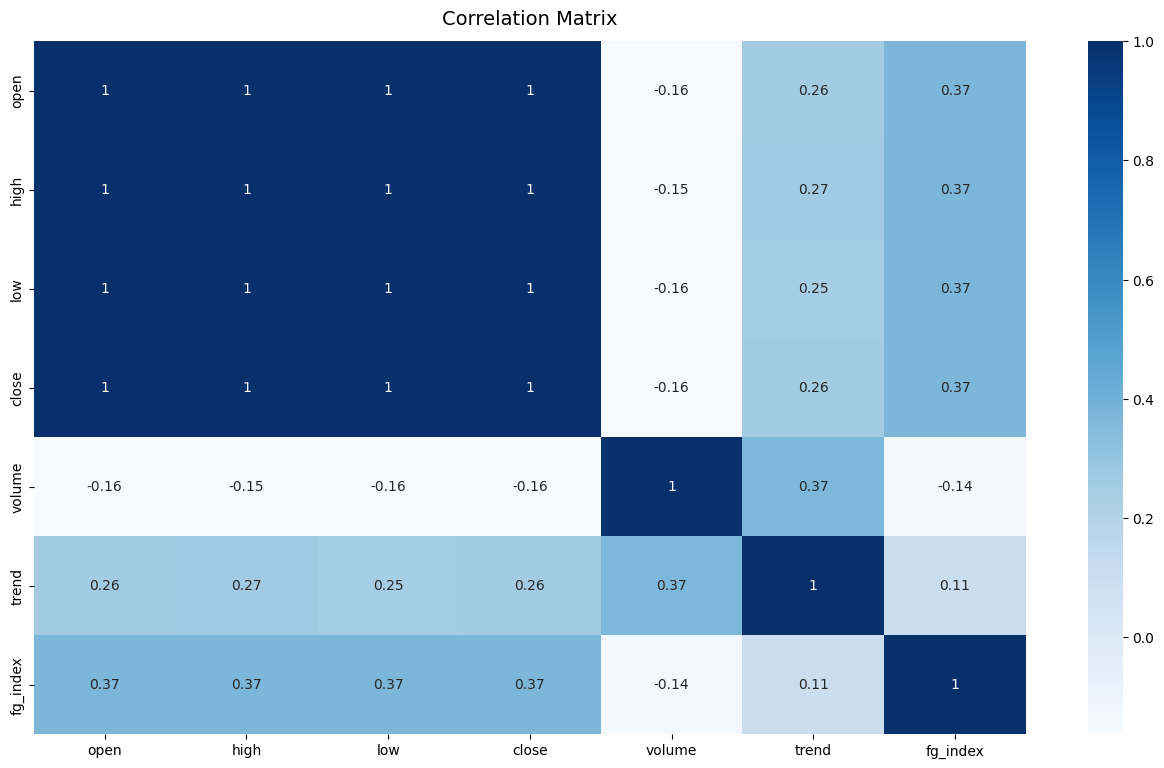

In [35]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
crldf = df.drop(["date"], axis = 1)
crl_plot = sns.heatmap(crldf.corr(), annot=True, cmap=sns.color_palette('Blues', as_cmap=True))
crl_plot.set_title('Correlation Matrix', fontdict={'fontsize':14}, pad=12);

The extremely high correlations among open, high, low, and close reflect the fact that they are tightly coupled measures from the same time frame. Including all of them in a model would introduce redundancy and potential multicollinearity. For this reason, these features will later be engineered and selectively dropped.  
  
In contrast, volume, trend, and fg_index do not raise concerns regarding multicollinearity, as confirmed by both the correlation matrix and their low Variance Inflation Factor (VIF) scores